In [1]:
import joblib as joblib
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [87]:
# lr_model = joblib.load('results/R_EF_B_RS.pkl')
lr_model = joblib.load('models/lr_dataset2.pkl')


### Confusion Matrix

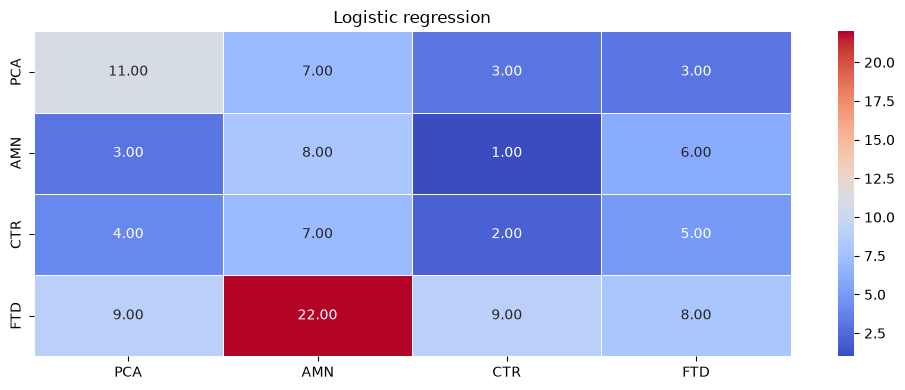

In [90]:
fig, ax = plt.subplots(1, figsize=(10, 4), sharex=True, sharey=True)

labels = ['PCA', 'AMN', 'CTR', 'FTD']

lr_cm = pd.DataFrame(lr_model['confusion_matrices'][0], index = labels, columns=labels)

sns.heatmap(lr_cm, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title('Logistic regression')

# plt.savefig('figures/analysis/confusion_matrix', dpi=150)
plt.tight_layout()

#### As percentages

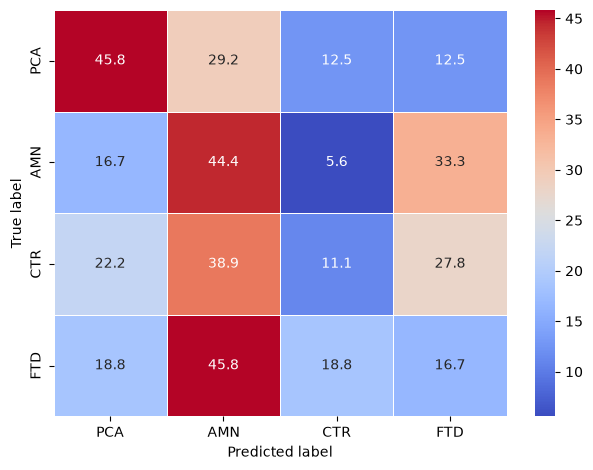

In [ ]:
labels = ['PCA', 'AMN', 'CTR', 'FTD']

lr_cm = pd.DataFrame(lr_model['confusion_matrices'][0], index = labels, columns=labels)

lr_cm_pct = lr_cm.div(lr_cm.sum(axis=1), axis=0) * 100

sns.heatmap(lr_cm_pct, annot=True, cmap="coolwarm", fmt=".1f", linewidths=0.5)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
# plt.savefig('figures/analysis/confusion_matrix.png', dpi=150)

### Learning curve

In [103]:
from pathlib import Path
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_28_lowess_trainingset_2.csv')
# df = pd.read_csv(x).drop(columns=['Unnamed: 0', 'LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)'])
df = pd.read_csv(x).dropna()

In [104]:
df

,condition,id,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDY_min,RDY_lat_min,RDY_max,RDY_lat_max,RDX_grad,RDY_grad,RDX_area_min,RDX_area_max,category_objet,category_visage,valence_negative,valence_neutre,valence_positive
0,ACP,ACP_10,-40.677058,296,-7.222944,1590,-27.112029,294,7.555835,1585,0.025853,0.026853,3464.666413,-171.453587,1.0,0.0,1.0,0.0,0.0
1,ACP,ACP_10,-68.837368,357,0.894283,541,-65.987125,372,-7.595386,527,0.378976,0.376721,14270.307605,-21.339036,1.0,0.0,0.0,1.0,0.0
2,ACP,ACP_10,-77.249803,302,-36.217353,1685,-72.618442,298,-33.833610,1702,0.029669,0.027625,17623.581922,3849.593813,1.0,0.0,0.0,0.0,1.0
3,ACP,ACP_10,-84.734017,313,-21.501112,1749,-74.621630,345,-25.629678,1239,0.044034,0.054801,19864.260393,1731.226703,0.0,1.0,1.0,0.0,0.0
4,ACP,ACP_10,-49.783366,257,-12.893195,1203,-49.038521,391,-16.975535,701,0.038996,0.103429,7669.578416,687.596877,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,DFT,DFT_9,-31.400511,288,-3.122672,1585,-52.931009,499,-24.462301,1539,0.021802,0.027374,5221.517838,239.979152,1.0,0.0,0.0,1.0,0.0
512,DFT,DFT_9,-28.040741,280,7.862483,1285,-44.175173,393,-26.061932,519,0.035725,0.143756,3891.505231,-643.748470,1.0,0.0,0.0,0.0,1.0
513,DFT,DFT_9,-40.021094,274,1.993172,1702,-44.277743,499,-19.988991,1512,0.029422,0.023977,5567.039447,-125.165763,0.0,1.0,1.0,0.0,0.0
514,DFT,DFT_9,-32.071399,327,4.697374,1624,-37.928827,356,-12.079604,1611,0.028349,0.020597,3821.529274,-178.261567,0.0,1.0,0.0,1.0,0.0


In [105]:
lr_model = joblib.load('models/lr_dataset2.pkl')

In [106]:
lr_model.keys()

dict_keys(['accuracy', 'proba', 'f1_score', 'balanced_accuracy', 'classification_report', 'train_cond_distribution', 'test_cond_distribution', 'confusion_matrices', 'train_idx_folds', 'X_train_folds', 'y_train_folds'])

In [ ]:
from sklearn.model_selection import learning_curve, StratifiedGroupKFold, LearningCurveDisplay

train_sizes = np.linspace(0.2, 1.0, 10)
cv_for_learning = StratifiedGroupKFold(n_splits=5)

X_train = lr_model['X_train_folds'][0]
y_train = lr_model['y_train_folds'][0]
# groups = df.loc[X_train.index, 'id'] # for fitted data

common_params = {
    "X": X_train,
    "y": y_train,
    "train_sizes": train_sizes,
    "cv": cv_for_learning,
    # "groups": groups,
    "score_type": "both",
    "n_jobs": -1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "f1_macro",
}

estimator = lr_model['best_model']

LearningCurveDisplay.from_estimator(estimator, **common_params, error_score='raise')
# handles, label = plt.get_legend_handles_labels()
# ax.legend(handles[:2], ["Training Score", "Test Score"])

plt.tight_layout()
# plt.savefig('figures/analysis/fitted_learning_curve.png', dpi=150)

KeyError: 'best_model'

### Ablation test

In [128]:
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_25_lowess_trainingset_1.csv')
df = pd.read_csv(x)
df = df.iloc[0::1792, :]


id = df.loc[:, 'id']
X = df.drop(columns=['id', 'condition'])
y = df.loc[:, 'condition']

columns = list(X.columns)
columns.append('baseline')

In [123]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

### SVC ###

numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_lat_max', 'RDX_max', 'RDX_grad']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', QuantileTransformer(n_quantiles=500, subsample=500, output_distribution="normal", copy=True, random_state=42))])
categorical_transformer = Pipeline([('passthrough', 'passthrough')])

cv = StratifiedGroupKFold(5)
SVC_score=[]

# Now ablation works correctly
for col in X.columns:
    df = X.copy()
    df = df.drop(columns=col)

    num = numeric_features.copy()
    cat = categorical_features.copy()

    if col in num:
        num.remove(col)

    if col in cat:
        cat.remove(col)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num),
            ('cat', categorical_transformer, cat)
        ],
        remainder='passthrough', verbose_feature_names_out=False
    )

    pipeline = ImbPipeline([
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('svc', SVC_model['best_model']['clf'])
    ])

    score = cross_val_score(pipeline, df, y, cv=cv, scoring="f1_macro", groups=id)
    SVC_score.append(np.mean(score))

### baseline correction ###
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC_model['best_model']['clf'])
])

score = np.mean(cross_val_score(pipeline, X, y, cv=cv, scoring="f1_macro", groups=id))
SVC_score.append(score)

SVC_score = [x - score for x in SVC_score]

SVC_score_desc = dict(zip(columns, SVC_score))
sorted_SVC = dict(sorted(SVC_score_desc.items(), key=lambda x: x[1], reverse=False))

/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (408). n_quantiles is set to n_samples.
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (414). n_quantiles is set to n_samples.
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (414). n_quantiles is set to n_samples.
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (414). n_quantiles is set to n_samples.
  warnings.warn(
/Users/arthur/git/2026_M1_internship

In [175]:
### Logisitc Regression ###

numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_lat_max', 'RDX_max', 'RDX_grad']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', QuantileTransformer(n_quantiles=500, subsample=500, output_distribution="normal", copy=True, random_state=42))])
categorical_transformer = Pipeline([('passthrough', 'passthrough')])

cv = StratifiedGroupKFold(5)
lr_score=[]

# Now ablation works correctly
for col in X.columns:
    df = X.copy()
    df = df.drop(columns=col)

    num = numeric_features.copy()
    cat = categorical_features.copy()

    if col in num:
        num.remove(col)

    if col in cat:
        cat.remove(col)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num),
            ('cat', categorical_transformer, cat)
        ],
        remainder='passthrough', verbose_feature_names_out=False
    )

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('lr', logistic_regression_model['best_model']['clf'])
    ])

    score = cross_val_score(pipeline, df, y, cv=cv, scoring="f1_macro", groups=id)
    lr_score.append(np.mean(score))

### compute baseline ###
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('lr', logistic_regression_model['best_model']['clf'])
])

score = np.mean(cross_val_score(pipeline, X, y, cv=cv, scoring="f1_macro", groups=id))
lr_score.append(score)

lr_score = [x - score for x in lr_score]

lr_score_desc = dict(zip(columns, lr_score))
sorted_lr = dict(sorted(lr_score_desc.items(), key=lambda x: x[1], reverse=False))

/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (408). n_quantiles is set to n_samples.
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (414). n_quantiles is set to n_samples.
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (414). n_quantiles is set to n_samples.
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (414). n_quantiles is set to n_samples.
  warnings.warn(
/Users/arthur/git/2026_M1_internship

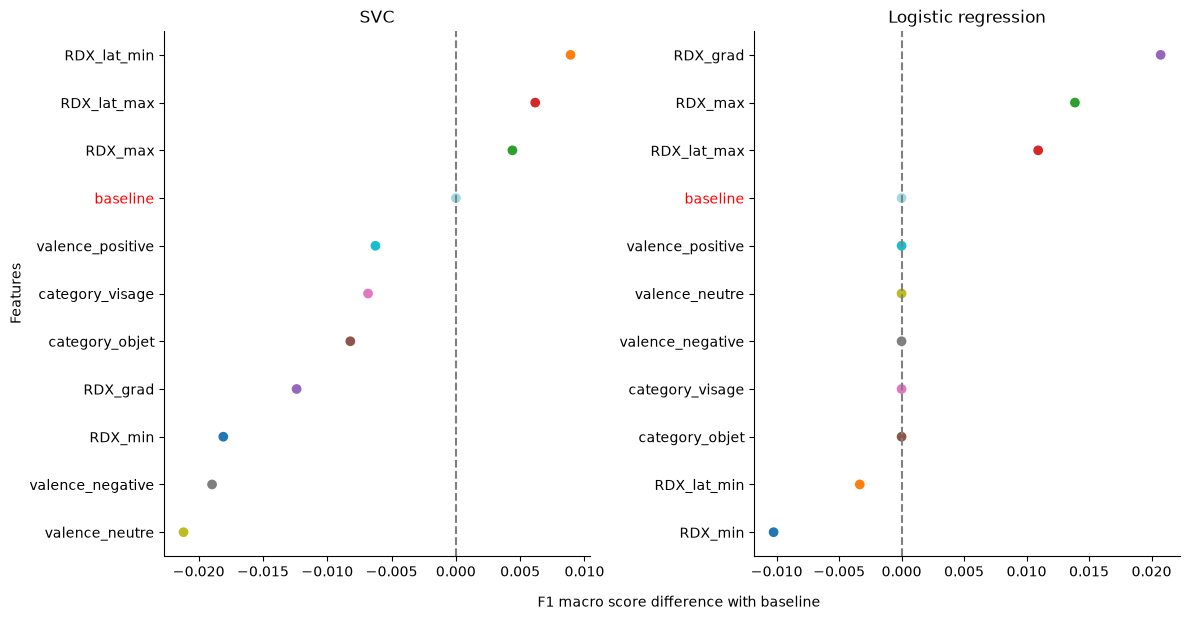

In [176]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

colours = plt.cm.tab20(np.linspace(0, 1, len(columns)))
colour_dict = {feature: colours[i] for i, feature in enumerate(columns)}

point_colours_svc = [colour_dict[feature] for feature in sorted_SVC.keys()]
point_colours_lr = [colour_dict[feature] for feature in sorted_lr.keys()]


ax[0].scatter(sorted_SVC.values(), sorted_SVC.keys(), c=point_colours_svc)
ax[0].axvline(sorted_SVC['baseline'], c='grey', ls='--')
# ax[0].tick_params(axis='y', rotation=90)
# ax[0].set_xscale('logit')

ax[1].scatter(sorted_lr.values(), sorted_lr.keys(), c=point_colours_lr)
ax[1].axvline(sorted_lr['baseline'], c='grey', ls='--')
# ax[1].tick_params(axis='y', rotation=90)
# ax[1].set_xscale('logit')

fig.text(0.57, -0.02, 'F1 macro score difference with baseline', ha='center')
# ax[0].set_xlabel('')
# ax[1].set_xlabel('F1 macro score difference with baseline')
ax[0].set_ylabel('Features')

ax[0].set_title('SVC')
ax[1].set_title('Logistic regression')

for a in ax:
    for label in a.get_yticklabels():
        if label.get_text() == 'baseline':
            label.set_color('red')

plt.tight_layout()
plt.savefig('figures/analysis/ablation.png', dpi=150)

### Permutation analysis

In [48]:
import matplotlib

from sklearn.inspection import permutation_importance
from sklearn.utils.fixes import parse_version


def plot_permutation_importance(clf, X, y, ax):
    result = permutation_importance(clf, X, y, scoring='f1_macro', n_repeats=10, random_state=42, n_jobs=2)
    perm_sorted_idx = result.importances_mean.argsort()

    # `labels` argument in boxplot is deprecated in matplotlib 3.9 and has been
    # renamed to `tick_labels`. The following code handles this, but as a
    # scikit-learn user you probably can write simpler code by using `labels=...`
    # (matplotlib < 3.9) or `tick_labels=...` (matplotlib >= 3.9).
    tick_labels_parameter_name = (
        "tick_labels"
        if parse_version(matplotlib.__version__) >= parse_version("3.9")
        else "labels"
    )
    tick_labels_dict = {tick_labels_parameter_name: X.columns[perm_sorted_idx]}
    # `vert` was deprecated in matplotlib 3.11 and is replaced by `orientation`,
    # which is available since matplotlib 3.10. The following code handles this,
    # but as a scikit-learn user you probably can write simpler code by using
    # `vert=False` (matplotlib < 3.11) or `orientation="horizontal"`
    # (matplotlib >= 3.10).
    orientation_dict = (
        {"orientation": "horizontal"}
        if parse_version(matplotlib.__version__) >= parse_version("3.10")
        else {"vert": False}
    )
    ax.boxplot(
        result.importances[perm_sorted_idx].T, **orientation_dict, **tick_labels_dict
    )
    ax.axvline(x=0, color="k", linestyle="--")
    return ax

In [6]:
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_25_lowess_trainingset_1.csv')
df_raw = pd.read_csv(x)

<Axes: >

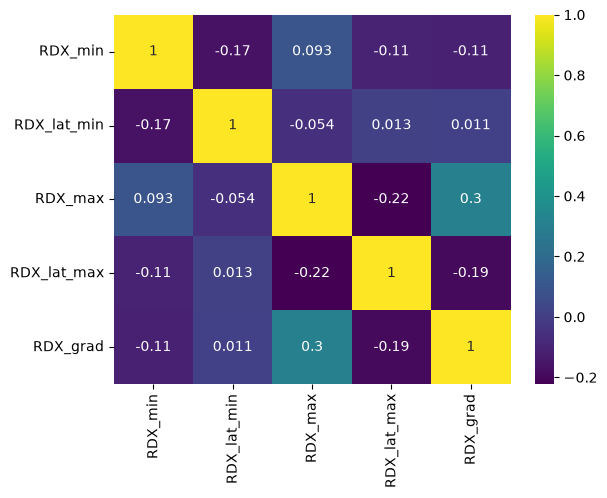

In [18]:
corr = df_raw.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad']].corr()
sns.heatmap(corr, cmap='viridis', annot=True)

In [9]:
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_29_lowess_curvefit_variables.csv')
# df = pd.read_csv(x).drop(columns=['Unnamed: 0', 'LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)'])
df_fit = pd.read_csv(x).dropna()

<Axes: >

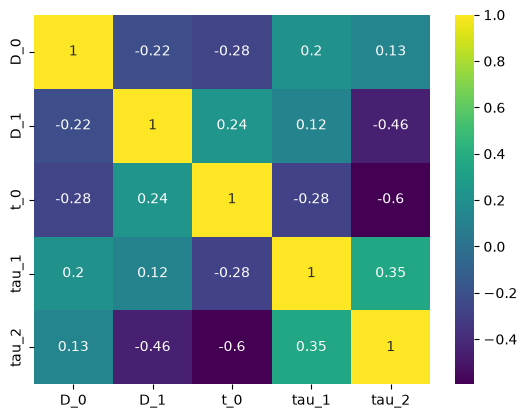

In [17]:
## correlation matrix
corr = df_fit.loc[:, ['D_0', 'D_1', 't_0', 'tau_1', 'tau_2']].corr()
sns.heatmap(corr, cmap='viridis', annot=True)

In [62]:
lr_model = joblib.load('results/fitted_B_RS.pkl')
lr_model['X_train_folds']

[          D_0       D_1         t_0      tau_1       tau_2  category_objet  \
 6   -4.363552  2.882475  106.782142  13.327647  316.298687             1.0   
 7   -3.196388  5.227050   48.979238  19.168469  373.001406             1.0   
 8   -0.003411  5.022338   66.381813  15.220549  487.925327             1.0   
 9    2.719918  4.381645   65.166886  19.999309  470.034726             0.0   
 10  -4.080549  6.729135   80.838544  19.420159  308.577141             0.0   
 ..        ...       ...         ...        ...         ...             ...   
 505 -0.287908  6.958063   80.583026  19.573065  181.146511             1.0   
 506  0.226779  2.663695   89.328052   8.437811  225.360594             1.0   
 507 -0.786057  3.541717   85.577374   8.160858  196.976628             0.0   
 508 -5.504238  6.572622   80.939837  19.818301  249.897702             0.0   
 509 -5.351553  2.252477   82.741314   7.010914  220.818843             0.0   
 
      category_visage  valence_negative  valence_n

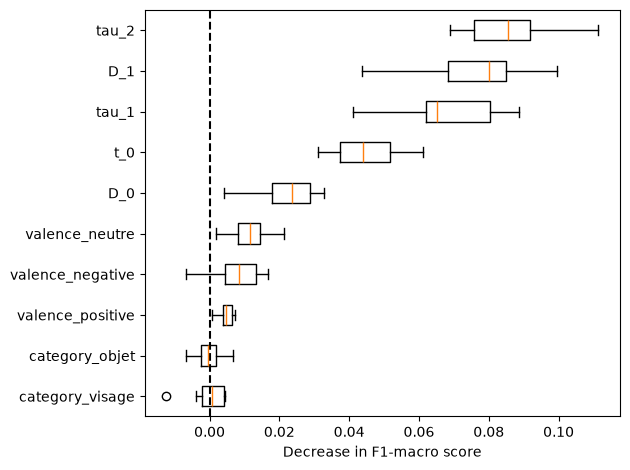

In [63]:
X_train = lr_model['X_train_folds'][0]
y_train = lr_model['y_train_folds'][0]
clf = lr_model['best_model'][0]
# groups = df.loc[X_train.index, 'id']

fig, ax = plt.subplots(1)

plot_permutation_importance(clf, X_train, y_train, ax)
ax.set_xlabel("Decrease in F1-macro score")
ax.figure.tight_layout()
plt.savefig('figures/analysis/fitted_perm_importance.png', dpi=150)
plt.show()